In [356]:
# install the tnesorflow
#!pip install tensorflow

In [2]:
import tensorflow as tf

In [3]:
# Dental  radiograph Images classification using both traditional Machine learning and Deep Learning  
# tasks involved 
# task 1 :  Dental  radiograph Images classification using both traditional 
# some of the steps may be common both the techniques 
# Dental radiograph images'  data collection from different sources 
# Dental  radiograph images  ingestion 
# Dental  radiograph images  cleaning 
# if requires more images , do augmnetation and add more images 
# try to cover all representation for the classifications 
# Consider atleast 4 types of dental radiographs  a) Bitewing X-Ray , b)  Periapical X-Ray c) Panoramic X-Ray d) Occlusal X-Ray e) others 
# Dental  radiograph Images classification belongs to multiclass 
# Refined imageset is similaiar for both the techniques 
# convert all the images into uniform width, height
# merge all the images into one array 
# add the labels value based on the dental x-ray images data 
# 1.panoramic 
# 2.bytewings 
# 3.Periapical
# 4.Occlusal
# 5. others 
#
# image features ( image descriptors , Image histograms) should be prepared by computer vision algorithms ( SIFT, Kmeans )
# refer the CV2 packages for preparing the image descriptors , histograms 
# Histograms of image features are the input for the traditional image classification ( SVM, Logistics regression)
# train the model with trained images' histograms ; refer the sklearn wrapper's SVM  and Logistics regression 
# predict the model's classification capability with the test images 
# prepare the confusion matrix for both the ground truth and predicted classifiers 
# calculate the accuracy, recall, F1-score 
# plot the model's computed confusion matrix values
# todolist 
# model evaluation  ;  add hyper parameters, boosting techniques if any,
# train both the models with more images 
# check the classified output with domain experts 

# task 2 :  Dental  radiograph Images classification using Deep Learing  
# install pytorch wrapper 
# install torch utilities for handling the dataset 
# choose the CNN model with input layers = , hidden layer =  ; output neurons  = 5 
# build the CNN model for computing the gradients (pre and post) using  feed forward with Softmax classification 
# todolist ; add sigmoid activation function  also 
# performance tuning ; add more layers , change the  kernel size 
# choose the Relu , Loss function  (cross-entrophy), learing_rate , epoch, batch_size 
# calculate the loss, accuracy for training and validation dataset
# check the model's overfit, underfit 

# task 3 
# choose the Random forest classifier, Support vector classification, and Logistics Regression models
# prepare feature descriptors  using the SURF, Kmeans, bag of Visual words techniques provided in CV2 package for the Dental images dataset
# Call the Sklearn's Random forest classifiers , SVM.SVC , and Logistics Regression  
# Split the dataset into 80 and 20 percentage 
# follow the Machine learing development life cycle , Fitting the model with traindata, Model prediction, chekc the metrics 
# related to classifier problem namely accuracy , precsion, Recall, F1 Score 
# refit the model with the supported hyper parameters like Regularization parameter, no_of_leaf_nodes, no_Pruning_trees , max_iteration 
# based on the model, do these steps until you get the better performance. 

# task 4  form the NN model using the  Keras Sequential Layers  , input for the image size ( 64 * 64 *3 ) , Dense layer with RELU activation function 
# and other dense layer for decoding the semantic lables with activation function = sigmoid (since multi class)
# build Pytorch with the layers for input , Training, Decoding,  develop a forward and backward modules. 
# train  or fit both the NN models with the train data, compile with  Adam activation function , choose the cross-entrophy loss and  softmax for decoding 
# the model's learned semantic labels 

# we have assigned 0  value for panoramic image ; 1 > bitewings ; 2>> Periapical 
# after seeing the accuracy value greater that 90% and loss and both are consistent then we start to infer the model predict capability 
# Generate the confusion matrix 

# task 5 
# compare all the five models' accuracy, Precision, F1-Score, Recall values and choose the best one. 
# tasks  6 : Enhancements in future  
# tasks : Conclusion : more dataset, data augmentation, add apprpriate hyper parameters, good representation of dataset, choose the dataset without bias 
# equal proportion 

# ingest the dataset from kaggle

raw_dataset = 'c:\\users\\19259\\project_data\\Dental_Xray3.tfrec' 
raw_dataset = tf.data.TFRecordDataset(raw_dataset)
#viewing the proto file for one image
for raw_record in raw_dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())
    #print(example)


In [76]:
#path tfrecords file
#C:\Users\19259\project_data\bytewings
path = 'c:\\users\\19259\\project_data\\Dental_Xray3.tfrec' 
raw_image_dataset = tf.data.TFRecordDataset(path)
#proto file has 3 features -> height, image_raw, width
def parse_image_function(proto):
    image_feature_description = {
        'height': tf.io.FixedLenFeature([], tf.int64),
        'image_raw': tf.io.FixedLenFeature([], tf.string),
        'width': tf.io.FixedLenFeature([], tf.int64)
    }
    return tf.io.parse_single_example(proto, image_feature_description)
#map the dataset
parsed_image_dataset = raw_image_dataset.map(parse_image_function)
print ( type ( parsed_image_dataset)) 

<class 'tensorflow.python.data.ops.map_op._MapDataset'>


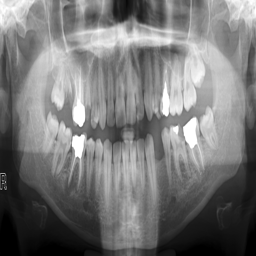

height:  256
width:  256


In [5]:

import numpy as np
import IPython.display as display
# enumerate the dataset and display the image 
# find the dimensions 
for image_features in parsed_image_dataset:
    image_raw = image_features['image_raw'].numpy()
    image_height = image_features['height'].numpy()
    image_width = image_features['width'].numpy()
    display.display(display.Image(data=image_raw))
    print("height: ",image_height)
    print("width: ",image_width)
    break
        

In [77]:
# refer the libraries 
import tensorflow as tf
import numpy as np
image_size = [256,256]
import cv2

# Define a function to extract the image data from TFRecord features
def extract_image_from_features(image_features):
    image_raw = image_features['image_raw']
    image_height = image_features['height']
    image_width = image_features['width']
    image = tf.image.decode_jpeg(image_raw, channels=3)  
    image = (tf.cast(image, tf.float32) / 128) - 1
    image = tf.reshape(image, [*image_size, 3])
    return image

# Load TFRecord file(s) and apply feature extraction
def load_and_extract_tfrecords(filenames):
    dataset = tf.data.TFRecordDataset(filenames)
    dataset = dataset.map(lambda x: tf.io.parse_single_example(x, {'image_raw': tf.io.FixedLenFeature([], tf.string),
                                                                    'height': tf.io.FixedLenFeature([], dtype=tf.int64),
                                                                    'width': tf.io.FixedLenFeature([], dtype=tf.int64)}))
    dataset = dataset.map(extract_image_from_features)
    return dataset

# Convert the dataset of images to a NumPy array
def tf_dataset_to_numpy(dataset):
    image_list = []
    for image in dataset:
        image_list.append(image.numpy())
    return np.array(image_list)

# Specify the TFRecord file(s) you want to read
tfrecord_filenames = ["your_file.tfrecord"]

# Load and extract TFRecord files
dataset = load_and_extract_tfrecords('c:\\users\\19259\\project_data\\Dental_Xray3.tfrec')

# Convert the dataset to a NumPy array of JPEG images
image_array1 = tf_dataset_to_numpy(dataset)

new_image_array1 = []
for image in image_array1:
    target_size = [64,64]
    
    image = cv2.resize(image, target_size)
    
    # Convert the image to a NumPy array and normalize pixel values to [0, 1]
    #image = image.astype(np.float32) / 255.0
    new_image_array1.append(image)


In [7]:
print ( type (new_image_array1))
print ( len (new_image_array1))


<class 'list'>
116


In [8]:
import matplotlib.pyplot as plt
# todolist generalize this visualize function  
def visualize_images(image_array):
    plt.figure(figsize = (5, 5))
    for i in range(10):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(image_array[i] * 0.5 + 0.5)
        plt.axis("off")

samplePanaromicXrays = new_image_array1
panaromicImages = samplePanaromicXrays

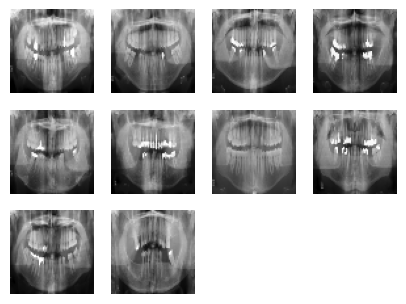

In [39]:
visualize_images(samplePanaromicXrays)

In [ ]:
visualize_images(samplePanaromicXrays)

In [78]:
import os
import cv2


path = 'c:\\users\\19259\\project_data\\bytewings'
image_files = []

# Loop through the files in the directory and filter for image file extensions
for filename in os.listdir(path):
    if filename.endswith(('.jpg', '.jpeg','.JPG','.png')):
        image_files.append(os.path.join(path, filename))

# Load the images as PIL image objects
images = []
target_size= [64,64]
for image_file in image_files:
    image = cv2.imread(image_file)
    if image.shape[2] == 1:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    image = cv2.resize(image, target_size)
    image_array = image.astype(np.float32) / 255.0
    images.append(image_array)

image_array2 = np.array(images)

image_array2.shape
bitewingImages  = image_array2

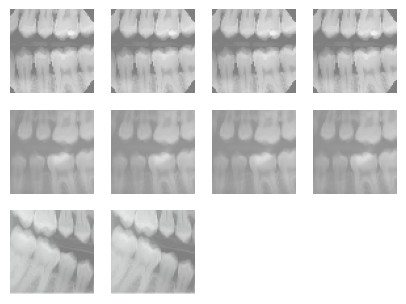

In [58]:
# display top images
visualize_images(bitewingImages)

In [79]:
# process periapical images 
path = 'c:\\users\\19259\\project_data\\periapical'
image_files = []

# Loop through the files in the directory and filter for image file extensions
for filename in os.listdir(path):
    if filename.endswith(('.jpg', '.jpeg','.JPG','.png')):
        image_files.append(os.path.join(path, filename))

# Load the images as PIL image objects
images = []
target_size= [64,64]
for image_file in image_files:
    image = cv2.imread(image_file)
    if image.shape[2] == 1:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    image = cv2.resize(image, target_size)
    image_array = image.astype(np.float32) / 255.0
    images.append(image_array)
image_array3 = np.array(images)
periapical_images =image_array3

image_array3.shape
print ('the size of  periapical images ' , len (periapical_images) )

the size of  periapical images  62


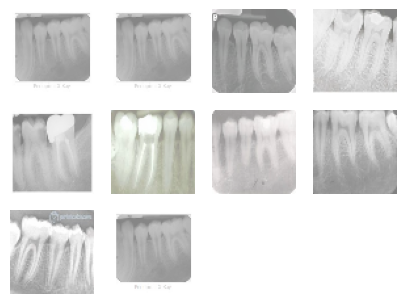

In [13]:
visualize_images(periapical_images)

In [14]:

# don't run this others code 
path = 'c:\\users\\19259\\project_data\\others'
image_files = []

# Loop through the files in the directory and filter for image file extensions
for filename in os.listdir(path):
    if filename.endswith(('.jpg', '.jpeg','.JPG','.png')):
        image_files.append(os.path.join(path, filename))

# Load the images as PIL image objects
images = []
target_size= [64,64]
for image_file in image_files:
    image = cv2.imread(image_file)
    if image.shape[2] == 1:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    image = cv2.resize(image, target_size)
    image_array = image.astype(np.float32) / 255.0
    images.append(image_array)

image_array3 = np.array(images)
image_array3.shape
arbitraryImages =image_array3

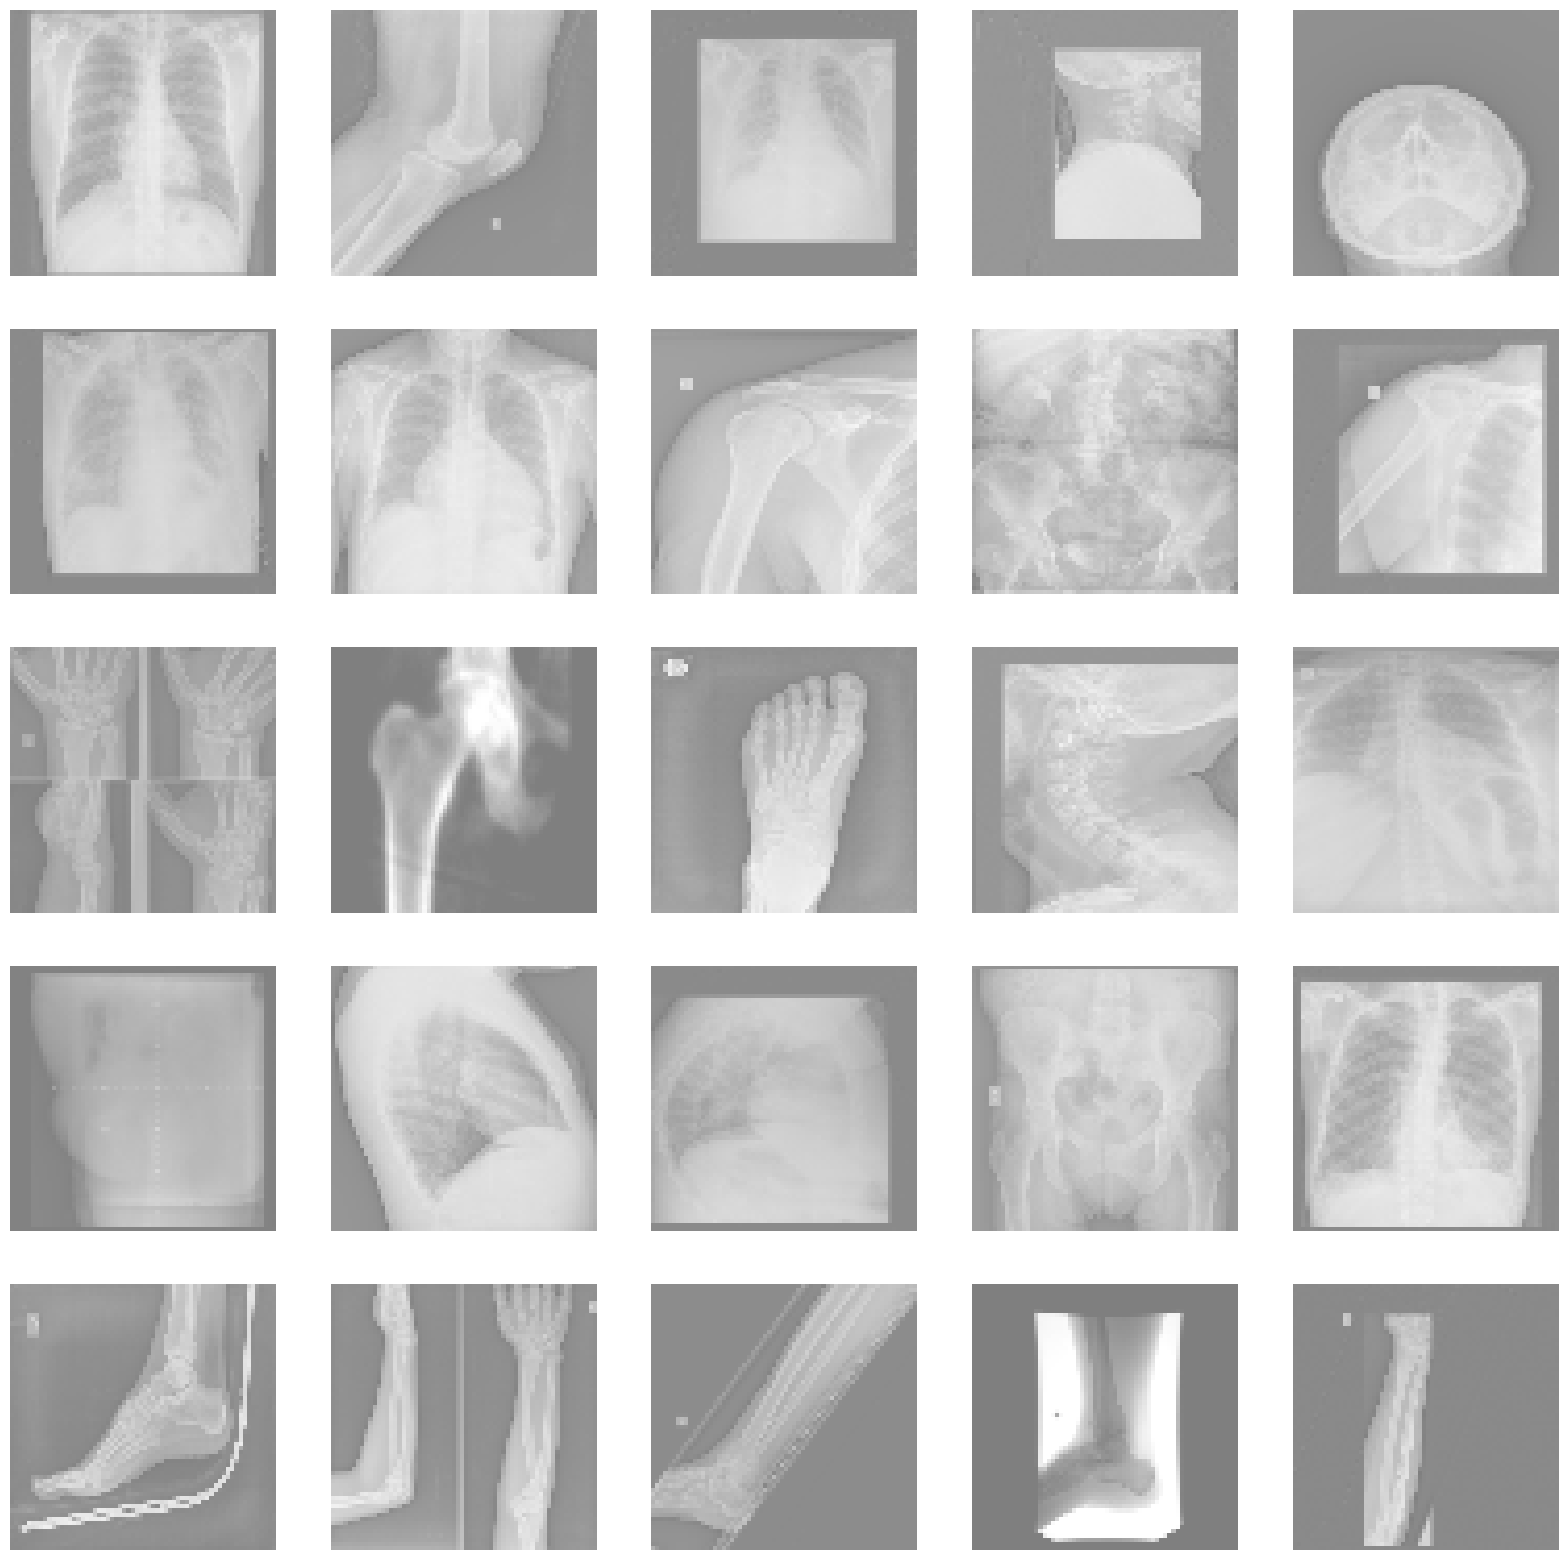

In [786]:
visualize_images(image_array3)

In [129]:
labels1 = np.zeros(116)
labels2 = np.ones(97)
labels3 = np.ones(100) * 2

combined_array = np.concatenate((new_image_array1, bitewingImages, periapical_images))
combined_labels = np.concatenate((labels1, labels2, labels3))

data = {'images': combined_array, 'labels': combined_labels}
print(data['images'].shape)

(226, 64, 64, 3)


In [81]:
labels1 = np.zeros(116) # 116 panaromic images
labels2 = np.ones(97) # 97 bitewing images
labels3 = np.ones(100) * 2 # 100 panoramic images
panaromicImages = new_image_array1
bitewingImages  = image_array2
combined_array = np.concatenate((panaromicImages, bitewingImages, image_array3))
combined_labels = np.concatenate((labels1, labels2, labels3))
data = {'images': combined_array, 'labels': combined_labels}
print(data['images'].shape)

(226, 64, 64, 3)


In [95]:
#shuffling image and corresponding label
from PIL import Image
labels1 = np.zeros(116) # 116 panaromic images
labels2 = np.ones(97) # 97 bitewing images
labels3 = np.ones(100) * 2 # 100 panoramic images
panaromicImages = new_image_array1
bitewingImages  = image_array2
combined_array = np.concatenate((panaromicImages, bitewingImages, image_array3))
combined_labels = np.concatenate((labels1, labels2, labels3))
data = {'images': combined_array, 'labels': combined_labels}
print(data['images'].shape)
permutation = np.random.permutation(len(data['images']))
data['images'] = data['images'][permutation]
data['labels'] = data['labels'][permutation]

data['images'].shape
data['labels'].shape

(226,)

In [68]:
!pip install torch

Defaulting to user installation because normal site-packages is not writeable


In [170]:
print  ('the  type of the image array is ' , type (new_image_array1))

the  type of the image array is  <class 'list'>


In [96]:

# refer the  pytorch and build the sequential model using its layers Liear , sigmoid (multi class )
# build NN using the pytorch's layers 
# fully connected for Image input and to the hidden 
# choose the sigmoid for semntic labels decoding or classification 
# choose fully conneted layer for output from hidden
# write forward propagation that takes gradient and calcuate the new weight vectors for both inout , bias 

import torch
# setting up the parameters 
max_iters = 50
batch_size = 32
learning_rate = 1e-3
hidden_size = 32
input_size = 12288 # 64 * 64 * 3 (the size of our images)
output_size = 3  # For 3 classes

class MyLayerNet(torch.nn.Module):
    def __init__(self, D_in, H, D_out):
        super(MyLayerNet, self).__init__()
        self.fc1 = torch.nn.Linear(D_in, H)
        self.sigmoid = torch.nn.Sigmoid()
        self.fc2 = torch.nn.Linear(H, D_out)
    
    def forward(self, x):
        h_sigmoid = self.sigmoid(self.fc1(x))
        y_pred = self.fc2(h_sigmoid)
        return y_pred

In [97]:
from sklearn.model_selection import train_test_split
images = data['images']
#flattening images before passing into training
images = images.reshape(226, -1)
labels = data['labels']

#stratify keeps distribution of classes similar
train_x, temp_images, train_y, temp_labels = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)
valid_x,  valid_y = temp_images , temp_labels

# Split the remaining data into validation and test sets
#valid_x, test_x, valid_y, test_y = train_test_split(
#    temp_images, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

print("Train Set:" , len(train_x), "images")
print("Validation Set:",  len(valid_x), "images")
#print("Test Set:", len(test_x), "images")

print  ( len ( np.argwhere(valid_y==0)) )
print  ( len ( np.argwhere(valid_y==1)) )
print  ( len ( np.argwhere(valid_y==2)) )


Train Set: 180 images
Validation Set: 46 images
23
20
3


In [98]:
# pass both the train and validation data to the tensor dataset 
# build both the data loader for both train and valid dataset 
import tensorflow as tf 
import torch
from torch import nn
from torch.utils.data import Dataset, TensorDataset , DataLoader
train_ds = TensorDataset(torch.from_numpy(train_x).type(torch.float32), torch.from_numpy(train_y).type(torch.LongTensor))
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
valid_ds = TensorDataset(torch.from_numpy(valid_x).type(torch.float32), torch.from_numpy(valid_y).type(torch.LongTensor))
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=True)

In [99]:
# specify the model paramater
# choose the Adam as part of training process learning and Cross-entrophy loss that calcuated between the ground truth and labels 
model = MyLayerNet(input_size, hidden_size, output_size)
# choose the Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# choose the CrossEntropyLoss ; loss between the predicted and groundtruth 
loss_func = nn.CrossEntropyLoss()  # Use CrossEntropyLoss for multi-class classification
print(model)
train_acc_list, valid_acc_list, train_loss_list, valid_loss_list = [], [], [], []

MyLayerNet(
  (fc1): Linear(in_features=12288, out_features=32, bias=True)
  (sigmoid): Sigmoid()
  (fc2): Linear(in_features=32, out_features=3, bias=True)
)


In [100]:
# training the model 
# enumerate the batches of images  (32) for 50 iterations 
# each time of the looping computute the gradient 
# compute the loss , accuracy 
# recompute the weights using both the forward , backward propagation  

for itr in range(max_iters):
    total_loss = 0.
    total_acc = 0.
    model.train()
    for xb, yb in train_loader:
        #Forward pass
        logits = model(xb)
        
        #Loss Calculation
        loss = loss_func(logits, yb.long())  # yb should be of dtype long for CrossEntropyLoss
        total_loss += loss.item()
        total_acc += (logits.argmax(dim=1) == yb).sum().item()  # Use argmax to get the most probable class
        
        #Backward Pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    total_loss /= len(train_loader)
    total_acc /= len(train_loader.dataset)
    
    model.eval()
    valid_loss, valid_acc = 0., 0.
    with torch.no_grad():
        for xb, yb in valid_loader:
            #Forward Pass
            logits = model(xb)
            
            #Loss Calculation
            loss = loss_func(logits, yb.long())
            valid_loss += loss.item()
            valid_acc += (logits.argmax(dim=1) == yb).sum().item()  # Again, use argmax for multi-class
            
    valid_loss /= len(valid_loader)
    valid_acc /= len(valid_loader.dataset)

    train_loss_list.append(total_loss)
    train_acc_list.append(total_acc)
    valid_loss_list.append(valid_loss)
    valid_acc_list.append(valid_acc)
    
    if itr % 2 == 0 or itr == max_iters - 1:
        print("Pytorch NN training:: itr: {:02d} \t loss: {:.2f} \t acc : {:.2f}".format(itr, total_loss, total_acc))
        print("Pytorch NN validation:: itr: {:02d} \t loss: {:.2f} \t acc : {:.2f}".format(itr, valid_loss, valid_acc))


Pytorch NN training:: itr: 00 	 loss: 0.49 	 acc : 0.84
Pytorch NN validation:: itr: 00 	 loss: 0.38 	 acc : 0.93
Pytorch NN training:: itr: 02 	 loss: 0.33 	 acc : 0.94
Pytorch NN validation:: itr: 02 	 loss: 0.33 	 acc : 0.93
Pytorch NN training:: itr: 04 	 loss: 0.29 	 acc : 0.94
Pytorch NN validation:: itr: 04 	 loss: 0.30 	 acc : 0.93
Pytorch NN training:: itr: 06 	 loss: 0.25 	 acc : 0.94
Pytorch NN validation:: itr: 06 	 loss: 0.24 	 acc : 0.93
Pytorch NN training:: itr: 08 	 loss: 0.24 	 acc : 0.94
Pytorch NN validation:: itr: 08 	 loss: 0.26 	 acc : 0.93
Pytorch NN training:: itr: 10 	 loss: 0.22 	 acc : 0.94
Pytorch NN validation:: itr: 10 	 loss: 0.21 	 acc : 0.93
Pytorch NN training:: itr: 12 	 loss: 0.22 	 acc : 0.94
Pytorch NN validation:: itr: 12 	 loss: 0.24 	 acc : 0.93
Pytorch NN training:: itr: 14 	 loss: 0.21 	 acc : 0.94
Pytorch NN validation:: itr: 14 	 loss: 0.24 	 acc : 0.93
Pytorch NN training:: itr: 16 	 loss: 0.20 	 acc : 0.94
Pytorch NN validation:: itr: 16 

In [ ]:
# plt both the metrics (loss , accuract ) for its evaluation 

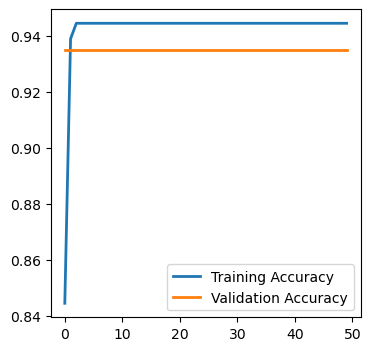

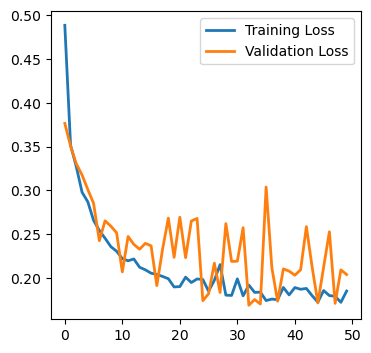

In [101]:
x = np.arange(max_iters)
plt.rcParams["figure.figsize"] = (4, 4)
plt.plot(x, train_acc_list, linewidth = 2, label = "Training Accuracy")
plt.plot(x, valid_acc_list, linewidth = 2, label = "Validation Accuracy")
plt.legend()
plt.show()

plt.plot(x, train_loss_list, linewidth = 2, label = "Training Loss")
plt.plot(x, valid_loss_list, linewidth = 2, label = "Validation Loss")
plt.legend()
plt.show()

In [117]:
# visulaize the confusion matrizxx values in sns's heatmap 
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def visualize(true_labels, predicted_labels):
    # Confusion Matrix
    ax= plt.subplot()
    matrix = confusion_matrix(true_labels, predicted_labels)
    #plt.figure(figsize=(10, 7))
    #sns.heatmap(matrix, annot=True, cmap='Blues', fmt='g')
    sns.heatmap(matrix, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

    ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
    ax.set_title('PyTorch Neural Network layers based Model - Confusion Matrix'); 
    
    #plt.xlabel(' Predicted')
    #plt.ylabel('Actual')
    #plt.title('PyTorch Neural Network layers based Model - Confusion Matrix')
    ax.xaxis.set_ticklabels(['Panoramic', 'Bytewings' , 'PeriaPical']); ax.yaxis.set_ticklabels(['Panoramic', 'Bytewings' , 'PeriaPical']);
    plt.show()



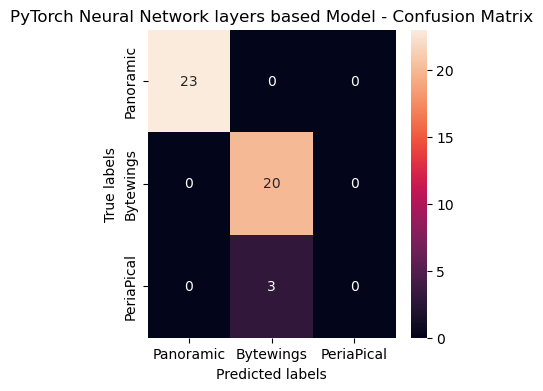

[23 20  3]


In [118]:
# form the confusion matrix 
import pandas as pd 
pred_y = []
groundtruth = []

# enumerate the valid_loader
for xb, yb  in valid_loader:
        output = model(xb) # Feed Network

        output = (torch.max(torch.exp(output), 1)[1]).data.cpu().numpy()
        #print (output)
        pred_y.extend(output) 
        
        labels = yb.data.cpu().numpy()
        #print (labels)
        groundtruth.extend(labels) # Save Truth

#  values for semantic classes
classifiers  = ('panoramic', 'bytewings','periapical')

# calcu
confusionmatrix = confusion_matrix(groundtruth, pred_y)
#print (confusionmatrix)
result = visualize (groundtruth, pred_y)
total = np.sum(confusionmatrix, axis=1)
print (total)
#confusionmatrix_df = pd.DataFrame(confusionmatrix / np.sum(confusionmatrix, axis=1)[:, None], index = [i for i in classifiers],
#                     columns = [i for i in classifiers])

#plt.figure(figsize = (12,7))
#sns.#heatmap(confusionmatrix_df, annot=True)
#confusionmatrix_df


In [214]:
print (confusionmatrix)
def calculate_metrics( cm) : 
    TN = cm[0][0]
    FN = cm[1][0]
    TP = cm[1][1]
    FP = cm[0][1]
    TPR = TP/(TP+FN)
    # Specificity or true negative rate
    TNR = TN/(TN+FP) 
    # Precision or positive predictive value
    PPV = TP/(TP+FP)
    # Negative predictive value
    NPV = TN/(TN+FN)
    # Fall out or false positive rate
    FPR = FP/(FP+TN)
    # False negative rate
    FNR = FN/(TP+FN)
    # False discovery rate
    FDR = FP/(TP+FP)
    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRE = TP/ (TP + FP ) 
    REC = TP/ (TP + FN ) 
    F1SCORE=  (2 * PRE * REC ) / (PRE+REC) 
    return ACC, PRE,REC ,F1SCORE

# unit testing 
ACC, PRE,REC ,F1SCORE = calculate_metrics ( confusionmatrix) 
print ('metrics of Pytorch  NN sequential layered model ' , ACC, PRE,REC ,F1SCORE)
#[[23  0  0]
# [ 0 20  0]
# [ 0  3  0]]
#metrics of Pytorch  NN sequential layered model  1.0 1.0 1.0 1.0
#

[[23  0  0]
 [ 0 20  0]
 [ 0  3  0]]
metrics of Pytorch  NN sequential layered model  1.0 1.0 1.0 1.0


In [131]:
from sklearn.model_selection import train_test_split
labels1 = np.zeros(116)
labels2 = np.ones(97)
labels3 = np.ones(100) * 2

combined_array = np.concatenate((new_image_array1, bitewingImages, periapical_images))
combined_labels = np.concatenate((labels1, labels2, labels3))

data = {'images': combined_array, 'labels': combined_labels}
print(data['images'].shape)

#shuffling image and corresponding label
from PIL import Image
labels1 = np.zeros(116) # 116 panaromic images
labels2 = np.ones(97) # 97 bitewing images
labels3 = np.ones(100) * 2 # 100 panoramic images
panaromicImages = new_image_array1
bitewingImages  = image_array2
combined_array = np.concatenate((panaromicImages, bitewingImages, image_array3))
combined_labels = np.concatenate((labels1, labels2, labels3))
data = {'images': combined_array, 'labels': combined_labels}
print(data['images'].shape)
permutation = np.random.permutation(len(data['images']))
data['images'] = data['images'][permutation]
data['labels'] = data['labels'][permutation]

data['images'].shape
data['labels'].shape




(226, 64, 64, 3)
(226, 64, 64, 3)


(226,)

In [141]:
from sklearn.model_selection import train_test_split
images = data['images']
#flattening images before passing into training
images = images.reshape(226, -1)
labels = data['labels']
images.shape

(226, 12288)

In [143]:
### 10 used only for img2vec method 
# flatten the data into an 64*64 ; adjust for nn 
train_x_flat = train_x.reshape(len(train_x), 3*64*64)
test_x_flat = valid_x.reshape(len(valid_x), 3*64*64)
# get the shape 
print (train_x_flat.shape ,train_y.shape )
print (train_x_flat.shape ,test_x_flat.shape )



(180, 12288) (180,)
(180, 12288) (46, 12288)


In [ ]:
# no need to run 
#stratify keeps distribution of classes similar
train_x, valid_x, train_y, valid_y = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)
#valid_x,  valid_y = temp_images , temp_labels

# Split the remaining data into validation and test sets
#valid_x, test_x, valid_y, test_y = train_test_split(
#    temp_images, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

print("Train Set:" , len(train_x), "images")
print("Validation Set:",  len(valid_x), "images")
#print("Test Set:", len(test_x), "images")

print  ( len ( np.argwhere(valid_y==0)) )
print  ( len ( np.argwhere(valid_y==1)) )
print  ( len ( np.argwhere(valid_y==2)) )


In [144]:
# Model 2 steps : 
# build NN model using the keras sequence layers ( input , dense .. ) 
import keras
# define the dense layer for the input with dimension 64*64 and three channels ( 64 * 64 * 3 = 12288)
# addd the dense layer for model training with RELU 
# add another dense layer for decoding and specify sigmoid sine multi-class classifiers problem statement 

# build the keras nn ; sequential rnn with dense output of three semantic values for the shape of flattened 64 *64 
dental_image_clf_model = keras.Sequential([
    #keras.layers.Dense(3, input_shape=(4096,), activation='sigmoid')
    # add a hidden layer 
    keras.layers.Dense(100, input_shape=(12288,), activation='relu'),
    keras.layers.Dense(3, activation='sigmoid')
])

# compile the model with Adam optimizer, loss and accuracy metrics 
dental_image_clf_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# fit the model with train daya 
dental_image_clf_model.fit(train_x_flat, train_y, epochs=50)


Epoch 1/50
6/6 [==============================] - 0s 8ms/step - loss: 1.0505 - accuracy: 0.7667
Epoch 2/50
6/6 [==============================] - 0s 9ms/step - loss: 1.4061 - accuracy: 0.9444
Epoch 3/50
6/6 [==============================] - 0s 8ms/step - loss: 0.8034 - accuracy: 0.9500
Epoch 4/50
6/6 [==============================] - 0s 9ms/step - loss: 0.5270 - accuracy: 0.8889
Epoch 5/50
6/6 [==============================] - 0s 9ms/step - loss: 0.2900 - accuracy: 0.9278
Epoch 6/50
6/6 [==============================] - 0s 9ms/step - loss: 0.4666 - accuracy: 0.9444
Epoch 7/50
6/6 [==============================] - 0s 9ms/step - loss: 0.4317 - accuracy: 0.9056
Epoch 8/50
6/6 [==============================] - 0s 9ms/step - loss: 0.2518 - accuracy: 0.9333
Epoch 9/50
6/6 [==============================] - 0s 8ms/step - loss: 0.3778 - accuracy: 0.9500
Epoch 10/50
6/6 [==============================] - 0s 8ms/step - loss: 0.4841 - accuracy: 0.8889
Epoch 11/50
6/6 [======================

In [147]:
# evaluate the model 
dental_image_clf_model.evaluate(test_x_flat, valid_y)

2/2 [==============================] - 0s 8ms/step - loss: 0.8340 - accuracy: 0.8478


[0.8339941501617432, 0.8478260636329651]

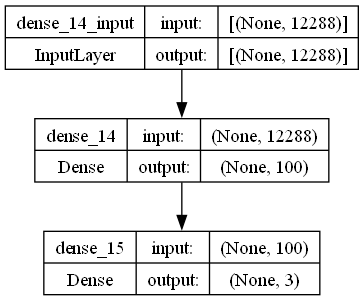

In [149]:
# plot the model 
keras.utils.plot_model(
 dental_image_clf_model, "ticket_classifier_with_shape_info.png", show_shapes=True)

In [153]:
# predict the model 

predictions_y = dental_image_clf_model.predict(test_x_flat) 

2/2 [==============================] - 0s 2ms/step


the  dimnesion of the  valid_y   (46,)
the  dimnesion of the  predictions_y.shape   (46, 3)


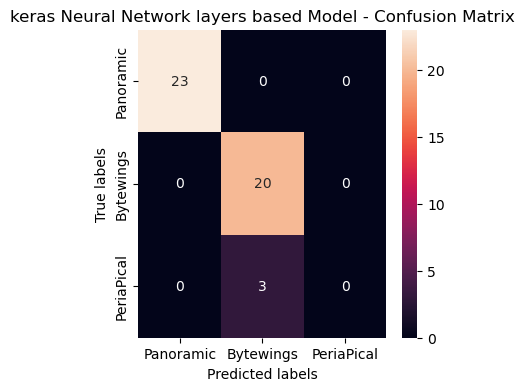

In [164]:
def visualize(true_labels, predicted_labels):
    # Confusion Matrix
    ax= plt.subplot()
    matrix = confusion_matrix(true_labels, predicted_labels)
    #plt.figure(figsize=(10, 7))
    #sns.heatmap(matrix, annot=True, cmap='Blues', fmt='g')
    sns.heatmap(matrix, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

    ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
    ax.set_title('keras Neural Network layers based Model - Confusion Matrix'); 
    
    #plt.xlabel(' Predicted')
    #plt.ylabel('Actual')
    #plt.title('PyTorch Neural Network layers based Model - Confusion Matrix')
    ax.xaxis.set_ticklabels(['Panoramic', 'Bytewings' , 'PeriaPical']); ax.yaxis.set_ticklabels(['Panoramic', 'Bytewings' , 'PeriaPical']);
    plt.show()

# call it 

print  (  'the  dimnesion of the  valid_y  ' ,  valid_y.shape)  
print  (  'the  dimnesion of the  predictions_y.shape  ' ,  predictions_y.shape  )

#visualize  (valid_y ,predictions_y)
predictions_y
pred_y = predictions_y.argmax(axis=-1)
pred_y

visualize(valid_y, pred_y)

In [166]:
#option 3 
# classical model 
# confirming the dataset 
from sklearn.model_selection import train_test_split
labels1 = np.zeros(116)
labels2 = np.ones(97)
labels3 = np.ones(100) * 2
combined_array = np.concatenate((new_image_array1, bitewingImages, periapical_images))
combined_labels = np.concatenate((labels1, labels2, labels3))

data = {'images': combined_array, 'labels': combined_labels}
print(data['images'].shape)

#shuffling image and corresponding label
from PIL import Image
labels1 = np.zeros(116) # 116 panaromic images
labels2 = np.ones(97) # 97 bitewing images
labels3 = np.ones(100) * 2 # 100 panoramic images
panaromicImages = new_image_array1
bitewingImages  = image_array2
combined_array = np.concatenate((panaromicImages, bitewingImages, image_array3))
combined_labels = np.concatenate((labels1, labels2, labels3))
data = {'images': combined_array, 'labels': combined_labels}
print(data['images'].shape)
permutation = np.random.permutation(len(data['images']))
data['images'] = data['images'][permutation]
data['labels'] = data['labels'][permutation]

data['images'].shape
data['labels'].shape





(226, 64, 64, 3)
(226, 64, 64, 3)


(226,)

In [167]:
# features, Iamge vocabulary, Histograms bins preparation
# these Image histograms are used for model fitting and evaluation 

import cv2
import numpy as np
# traditional Machine learnign modle 
# function to gather features using the Scale in-variant Feature Transform 
def extract_sift_features(images):
    sift = cv2.SIFT_create()
    all_descriptors = []
    img_descriptors = []    
    # compute the descriptors for image using the SIFT 
    for img in images:
        if img.dtype != np.uint8:
            img = (img * 255).astype(np.uint8)
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        # returns the key points, key descriptors 
        _, des = sift.detectAndCompute(img, None)
        if des is not None:
            all_descriptors.extend(des)
            img_descriptors.append(des)
        else:
            img_descriptors.append([])
    
    return img_descriptors, np.array(all_descriptors)

In [168]:
import sklearn
from sklearn.cluster import MiniBatchKMeans
# form feature vocabulary using Kmeans algorithm 
def build_vocab(descriptors, k=100):
    kmeans = MiniBatchKMeans(n_clusters=k, batch_size=k * 20, compute_labels=False, reassignment_ratio=10**-4, random_state=645)
    kmeans.fit(descriptors)
    return kmeans

In [169]:
# function to create histograms for image features 
def images_to_histograms(image_descriptors, kmeans_model):
    histograms = []
    for descriptors in image_descriptors:
        if len(descriptors) > 0:
            clusters = kmeans_model.predict(descriptors)
            hist, _ = np.histogram(clusters, bins=np.arange(kmeans_model.n_clusters + 1))
            histograms.append(hist)
        else:
            histograms.append(np.zeros((kmeans_model.n_clusters,)))
    return np.array(histograms)

In [173]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


# call the SIFT function 
# unit testing 
# Extract SIFT feature descriptors 

k = 10 
img_descriptors, all_descriptors = extract_sift_features(data['images'])
print (type ( img_descriptors))
print (len( all_descriptors))
#all_descriptors[0]
#todolist , debug the issue 
all_descriptors_f = list ( filter( lambda item: item is not None, all_descriptors) )
print (type (all_descriptors))
print (len( all_descriptors))
print (np.__version__)
# build the vocabularies for the feature descriptors of the image 
kmeans = build_vocab(all_descriptors, k)
# Convert images to histogram representation
histograms = images_to_histograms(img_descriptors, kmeans)
# Split data
X_train, X_test, y_train, y_test = train_test_split(histograms, data['labels'], test_size=0.2, random_state=42)

# Train SVM
clf = make_pipeline(StandardScaler(), SVC(kernel='linear'))
# fit the model 
clf.fit(X_train, y_train)

# Test SVM
# predict the model 
y_pred = clf.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.2f}")


<class 'list'>
10674
<class 'numpy.ndarray'>
10674
1.26.2


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1902: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2048 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


Accuracy: 0.96


the  dimnesion of the  valid_y   (46,)
the  dimnesion of the  predictions_y.shape   (46, 3)


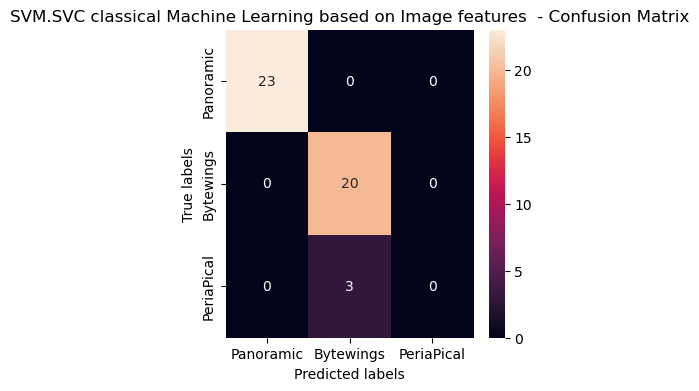

In [174]:
def visualize(true_labels, predicted_labels):
    # Confusion Matrix
    ax= plt.subplot()
    matrix = confusion_matrix(true_labels, predicted_labels)
    #plt.figure(figsize=(10, 7))
    #sns.heatmap(matrix, annot=True, cmap='Blues', fmt='g')
    sns.heatmap(matrix, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

    ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
    ax.set_title('SVM.SVC classical Machine Learning based on Image features  - Confusion Matrix'); 
    
    #plt.xlabel(' Predicted')
    #plt.ylabel('Actual')
    #plt.title('PyTorch Neural Network layers based Model - Confusion Matrix')
    ax.xaxis.set_ticklabels(['Panoramic', 'Bytewings' , 'PeriaPical']); ax.yaxis.set_ticklabels(['Panoramic', 'Bytewings' , 'PeriaPical']);
    plt.show()

# call it 

print  (  'the  dimnesion of the  valid_y  ' ,  valid_y.shape)  
print  (  'the  dimnesion of the  predictions_y.shape  ' ,  predictions_y.shape  )

#visualize  (valid_y ,predictions_y)
#predictions_y
#pred_y = predictions_y.argmax(axis=-1)
#pred_y

visualize(valid_y, pred_y)

In [177]:
# option 4 ; use random forest classifier  
# use the features' histograms bin for model fitting and evaluation 

# call the  random foest classifier for the histogram 
# pass the feature vectors to the classical rndom 
from sklearn.ensemble import RandomForestClassifier
# split the data for train and test 
# fit the rfc for training data 
# form the pipeline for standardize the data values , and call the Support vector classifiers 
X_train, X_test, y_train, y_test = train_test_split(histograms, data['labels'], test_size=0.2, random_state=42)

rfc_model = RandomForestClassifier()
rfc_model.fit(X_train, y_train)
# predic the model with test data 
pred_y = rfc_model.predict(X_test)
accuracy = np.mean(pred_y == y_test)
print(f"Accuracy: {accuracy:.2f}")
# Randomn forest classifier  Classification Report
# unit testing 
# pass the y_test (ground truth and y_pred values )
matrix = confusion_matrix(y_test, pred_y)
#report = visualize(y_test, pred_y)
print(matrix)
#visualize(y_test, y_pred)


Accuracy: 0.98
[[29  0  0]
 [ 0 15  1]
 [ 0  0  1]]


the  dimnesion of the  valid_y   (46,)
the  dimnesion of the  predictions_y.shape   (46, 3)


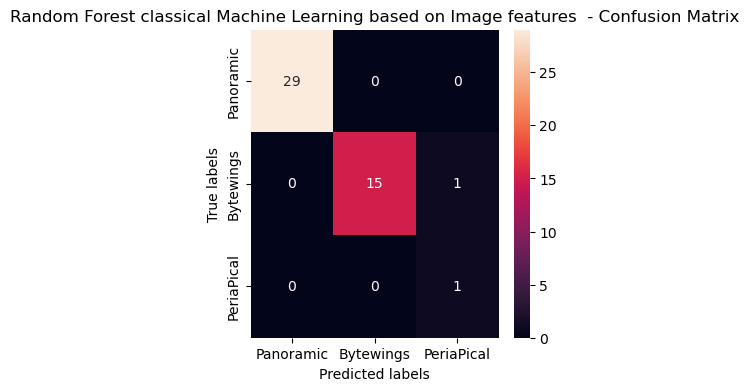

In [178]:
def visualize(true_labels, predicted_labels):
    # Confusion Matrix
    ax= plt.subplot()
    matrix = confusion_matrix(true_labels, predicted_labels)
    #plt.figure(figsize=(10, 7))
    #sns.heatmap(matrix, annot=True, cmap='Blues', fmt='g')
    sns.heatmap(matrix, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

    ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
    ax.set_title('Random Forest classical Machine Learning based on Image features  - Confusion Matrix'); 
    
    #plt.xlabel(' Predicted')
    #plt.ylabel('Actual')
    #plt.title('PyTorch Neural Network layers based Model - Confusion Matrix')
    ax.xaxis.set_ticklabels(['Panoramic', 'Bytewings' , 'PeriaPical']); ax.yaxis.set_ticklabels(['Panoramic', 'Bytewings' , 'PeriaPical']);
    plt.show()

# call it 

print  (  'the  dimnesion of the  valid_y  ' ,  valid_y.shape)  
print  (  'the  dimnesion of the  predictions_y.shape  ' ,  predictions_y.shape  )

#visualize  (valid_y ,predictions_y)
#predictions_y
#pred_y = predictions_y.argmax(axis=-1)
#pred_y

visualize(y_test, pred_y)

In [179]:
# option LogisticRegression 
# daatset : imagesets features descriptors, bins 

# try the logistics regression from skleran 
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
# instantiate LR type and intialize its parameters namely penelty, max_iter
LR_clf = LogisticRegression(fit_intercept=True,
                        multi_class='auto',
                        penalty='l2',  # L2 ridge regression 
                        #solver='saga', not required since the image dataset is very small 
                        max_iter=10000,
                        C=50) # regularization strength value 

In [180]:
# split the data for train and test 
# fit the LogisticRegression for training data 
# form the pipeline for standardize the data values , and call the Support vector classifiers 
X_train, X_test, y_train, y_test = train_test_split(histograms, data['labels'], test_size=0.2, random_state=42)

LR_clf.fit(X_train, y_train)
# predic the model with test data 
pred_y = LR_clf.predict(X_test)
accuracy = np.mean(pred_y == y_test)
print(f"Accuracy: {accuracy:.2f}")
# Randomn forest classifier  Classification Report
# unit testing 
# pass the y_test (ground truth and y_pred values )
matrix = confusion_matrix(y_test, pred_y)


Accuracy: 0.96


the  dimnesion of the  valid_y   (46,)
the  dimnesion of the  predictions_y.shape   (46, 3)


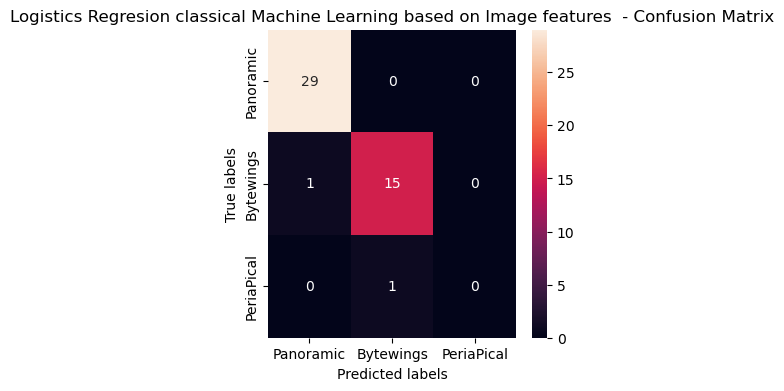

In [181]:
def visualize(true_labels, predicted_labels):
    # Confusion Matrix
    ax= plt.subplot()
    matrix = confusion_matrix(true_labels, predicted_labels)
    #plt.figure(figsize=(10, 7))
    #sns.heatmap(matrix, annot=True, cmap='Blues', fmt='g')
    sns.heatmap(matrix, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

    ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
    ax.set_title('Logistics Regresion classical Machine Learning based on Image features  - Confusion Matrix'); 
    
    #plt.xlabel(' Predicted')
    #plt.ylabel('Actual')
    #plt.title('PyTorch Neural Network layers based Model - Confusion Matrix')
    ax.xaxis.set_ticklabels(['Panoramic', 'Bytewings' , 'PeriaPical']); ax.yaxis.set_ticklabels(['Panoramic', 'Bytewings' , 'PeriaPical']);
    plt.show()

# call it 

print  (  'the  dimnesion of the  valid_y  ' ,  valid_y.shape)  
print  (  'the  dimnesion of the  predictions_y.shape  ' ,  predictions_y.shape  )

#visualize  (valid_y ,predictions_y)
#predictions_y
#pred_y = predictions_y.argmax(axis=-1)
#pred_y

visualize(y_test, pred_y)

the  values of true positive rate and false positive rate   [0.         0.03333333 1.        ] [0.     0.9375 1.    ]


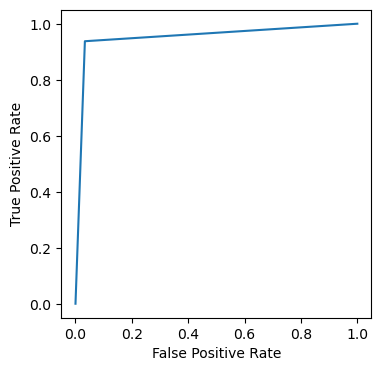

In [205]:
# instead of binary , implement for OneVsRest 
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay
y_score = LR_clf.decision_function(X_test)
#print (X_test)
pred_y = y_score.argmax(axis=-1)
fpr, tpr, _ = roc_curve(y_test, pred_y, pos_label=clf.classes_[1])
print ('the  values of true positive rate and false positive rate  ' ,fpr, tpr)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

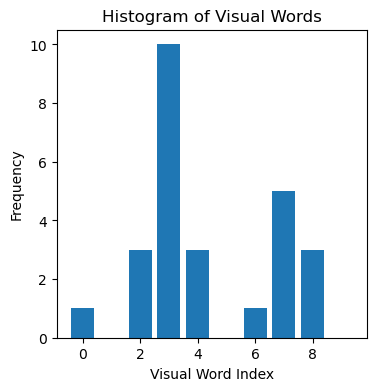

In [182]:
def visualize_histogram(histogram, k):
    plt.bar(range(k), histogram)
    plt.xlabel('Visual Word Index')
    plt.ylabel('Frequency')
    plt.title('Histogram of Visual Words')
    plt.show()

visualize_histogram(histograms[0], k)

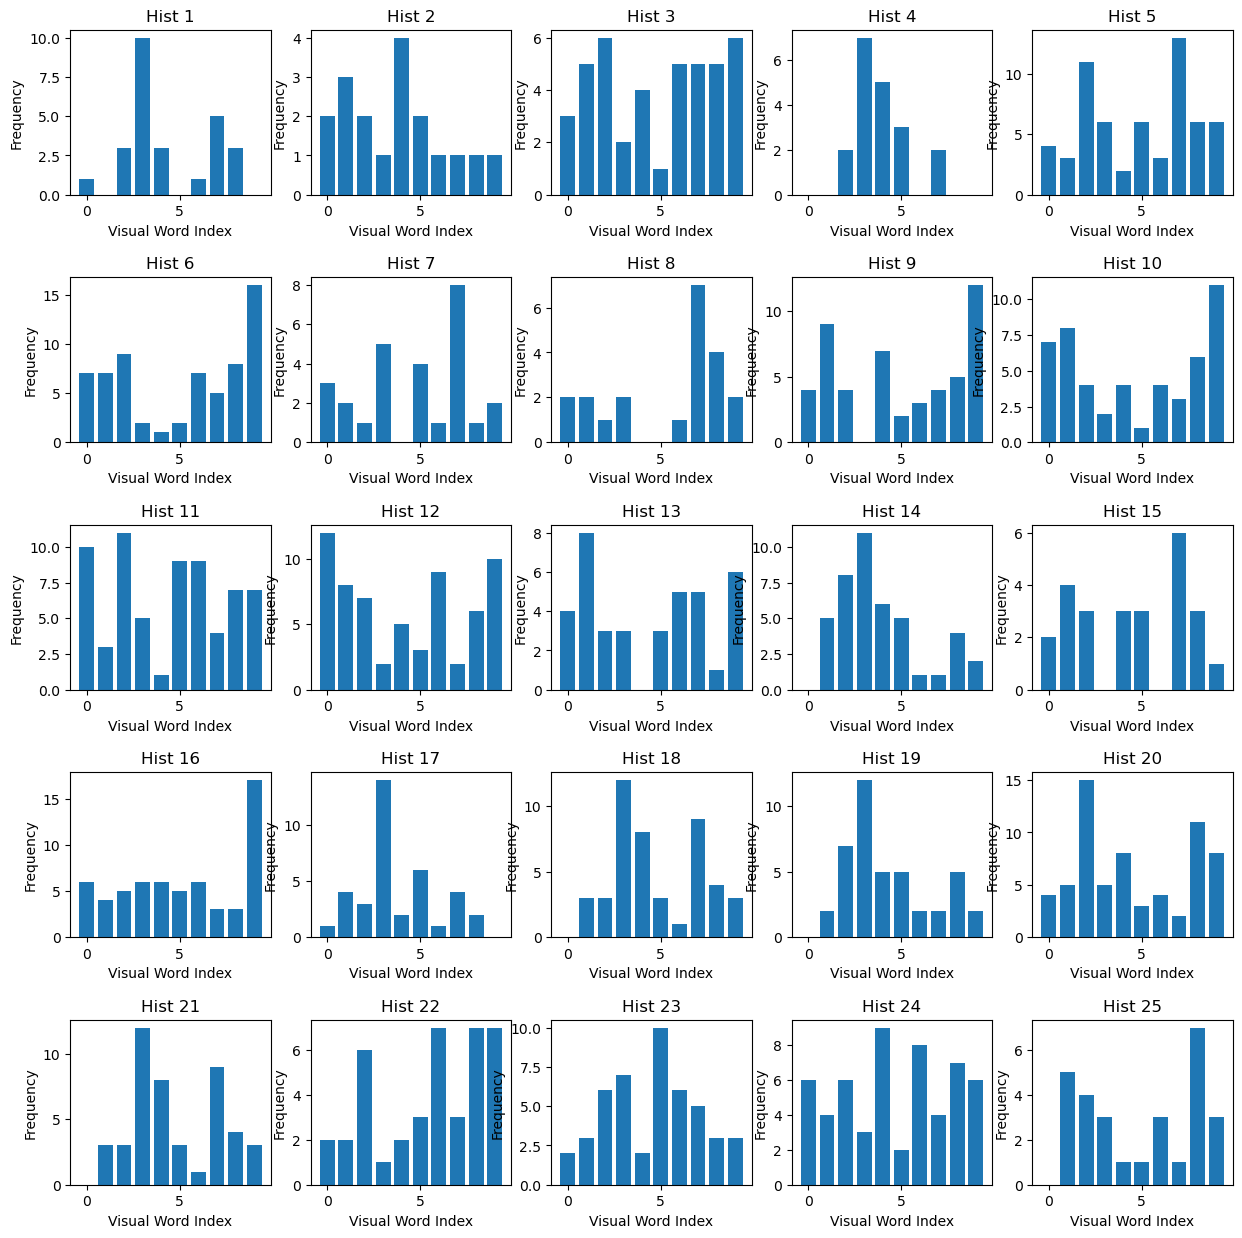

In [183]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have a list of histograms called "histograms"
# Each histogram should be a list or array of varying length

def visualize_histograms(histograms):
    num_histograms = len(histograms)
    num_rows = 5
    num_cols = 5
    num_plots = min(num_histograms, num_rows * num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 15))
    plt.subplots_adjust(hspace=.5)

    for i in range(num_plots):
        row = i // num_cols
        col = i % num_cols
        histogram = histograms[i]
        ax = axes[row, col]

        k = len(histogram)  # Get the length of the current histogram

        ax.bar(range(k), histogram)
        ax.set_xlabel('Visual Word Index')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Hist {i + 1}')

    # Remove empty subplots if necessary
    for i in range(num_plots, num_rows * num_cols):
        row = i // num_cols
        col = i % num_cols
        fig.delaxes(axes[row, col])

    plt.show()

# Example usage:
# Assuming histograms is a list of histograms with varying lengths
visualize_histograms(histograms)


In [ ]:
# unit testing 
# pass the bytwwing image and ensure whether the lable is identified as 2 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
sift = cv2.SIFT_create()
gray = cv2.cvtColor(bitewing_img,cv2.IMREAD_GRAYSCALE)
_, descriptors = sift.detectAndCompute(gray, None)
clusters = kmeans.predict(descriptors)
hist, _ = np.histogram(clusters, bins=np.arange(kmeans.n_clusters + 1))
hist = hist.reshape(1, -1)
predicted_class = svc_model.predict(hist)
print(predicted_class)

In [119]:
# option 2 
# instead of pass the three channels just pass the grey scale ,one channel
# 1 used only for img2vec method 
def convert_one_channel(img):
    #some images have 3 channels , although they are grayscale image
    if len(img.shape)>2:
        img=img[:,:,0]
        return img
    else:
        return img


In [120]:
# call the one_channel function 
# or hw4 
## 2 used only for img2vec method 
data_one = []
for image in combined_array:
        #print (image)
        #traindata_.append(row [1:len(row )])
        image_one = np.array(image)
        image_one = image_one.astype(np.float32) / 255.0
        image_one = convert_one_channel (image_one)
        image_one = image_one.astype(np.float32) / 255.0
        #image_data /= 255.0
        data_one.append( image_one)
data_one = np.array(data_one)
print ('the shape of the  data_one  is' , data_one.shape)


the shape of the  data_one  is (226, 64, 64)


In [18]:
#3 ##  used only for img2vec method 
combined_labels = np.concatenate((labels1, labels2, labels3))
label_one = combined_labels 
label_one[:2]

array([0., 0.])

In [19]:
# split the data 
## 5 used only for img2vec method 
data = {'images': data_one, 'labels': label_one}
print(data['images'].shape)
#shuffling image and corresponding label
from PIL import Image

permutation = np.random.permutation(len(data['images']))
#print (permutation)
data['images'] = data['images'][permutation]
data['labels'] = data['labels'][permutation]



(226, 64, 64)


In [250]:
## 6 used only for img2vec method 
print (len (bitewingImages))
print (len (panaromicImages))
print (len (periapical_images))

48
116
62


In [21]:
## 7 used only for img2vec method 
# keeping all the images into one bucket 
# todolit ; add more images and all types 
# on the fly calculate the length of the labels 

labels1 = np.zeros(48) # 116 panaromic images
labels2 = np.ones(116) # 97 bitewing images
labels3 = np.ones(62) * 2 # 100 peripical images
#todolist 
# need to add Periapical  and  Cone Beam X-ray dental images  
# combine all the image data  and its labels 
combined_array = np.concatenate((panaromicImages, bitewingImages, periapical_images))
combined_labels = np.concatenate((labels1, labels2, labels3))
data = {'images': combined_array, 'labels': combined_labels}
print(data['images'].shape)
print (data_one.shape)
#data['images'] = data_one
#data['labels'] = combined_labels
#combined_labels.shape


(226, 64, 64, 3)
(226, 64, 64)


In [26]:

# ## 8 used only for img2vec method  
#shuffling image and corresponding label
#from PIL import Image
#permutation = np.random.permutation(len(data['images']))
#data['images'] = data['images'][permutation]
#data['labels'] = data['labels'][permutation]

#shuffling image and corresponding label
#from PIL import Image
data['images'] = data_one
data['labels'] = combined_labels
combined_labels.shape


(226,)

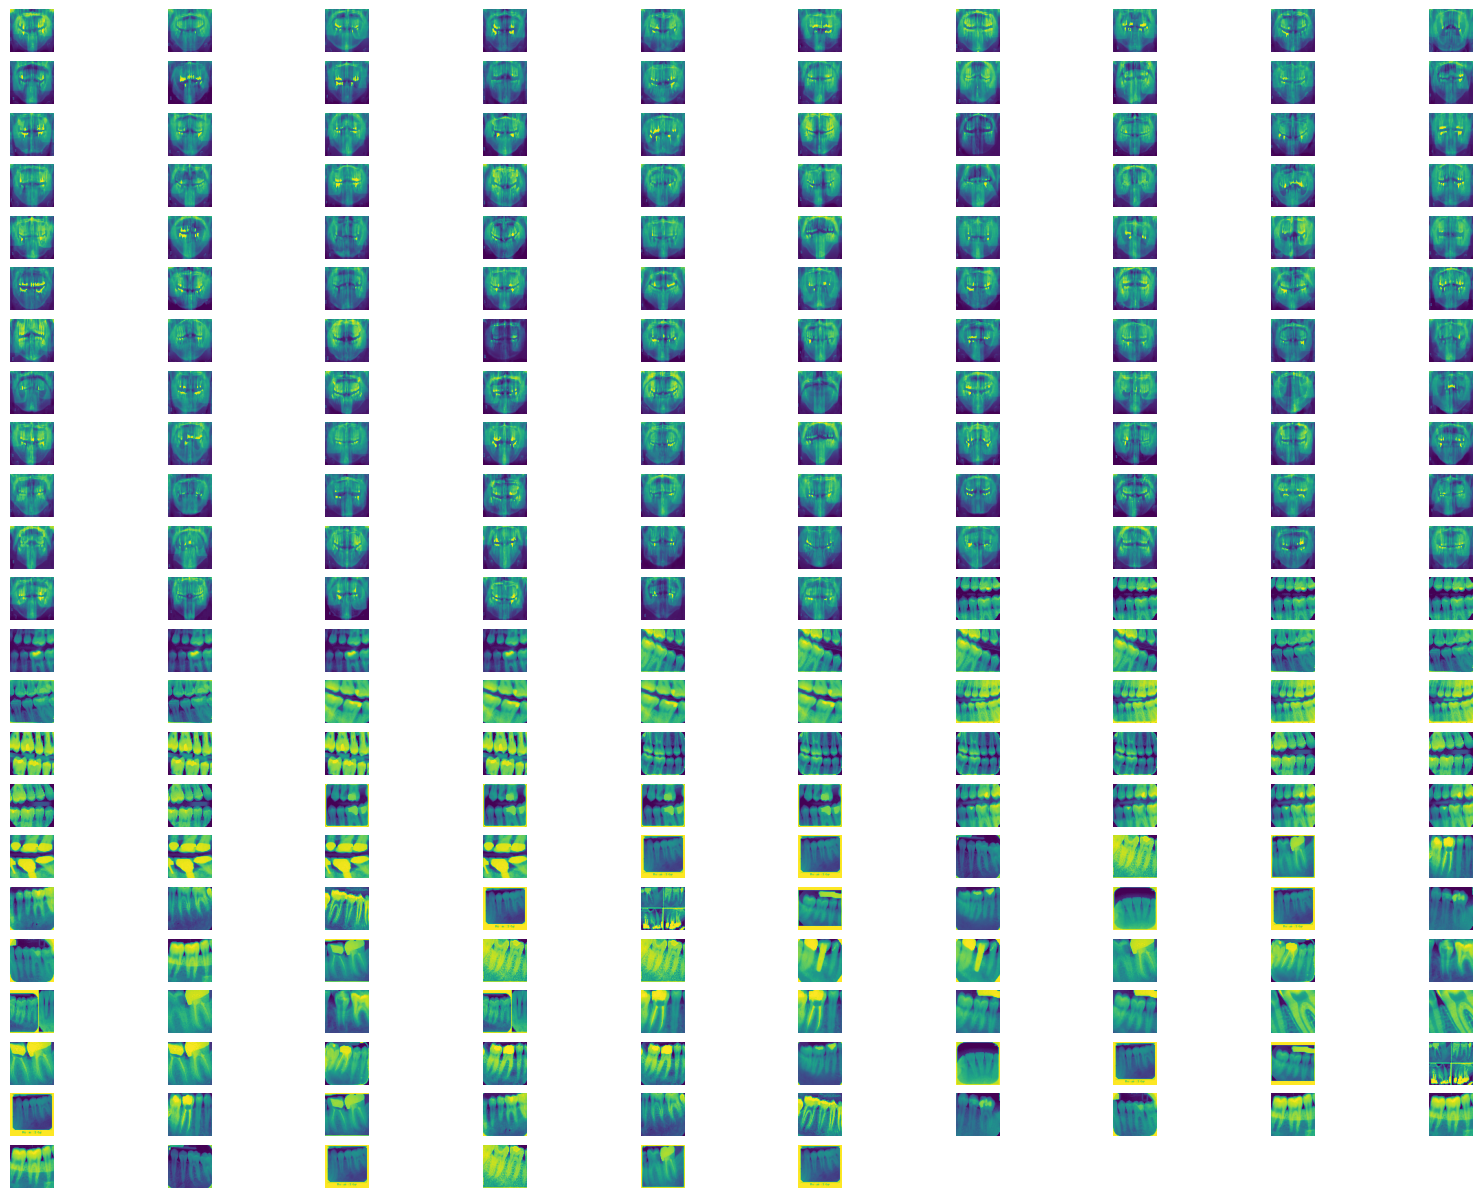

In [23]:
# plot all the buckets of images 
def visualize_images_v1(image_array):
    plt.figure(figsize = (20, 20))
    for i in range(len (image_array)):
        ax = plt.subplot(30, 10, i + 1)
        plt.imshow(image_array[i] * 0.5 + 0.5)
        plt.axis("off")
        
visualize_images_v1(data['images'])

In [30]:
### 10 used only for img2vec method 
# flatten the data into an 64*64 ; adjust for nn 
train_x_flat = train_x.reshape(len(train_x), 64*64)
test_x_flat = test_x.reshape(len(test_x), 64*64)
# get the shape 
print (train_x_flat.shape ,train_y.shape )

(180, 4096) (180,)


the  of  corresponding  image is  1.0


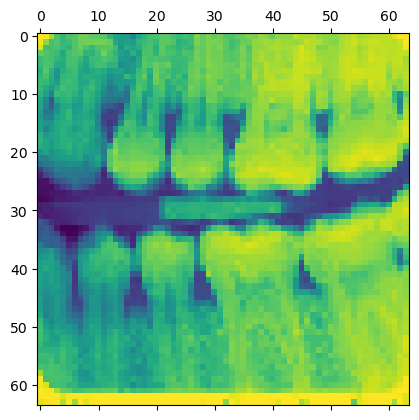

In [33]:
# predict the image with the model 
# Show the image
plt.matshow(test_x[0])
print ( 'the  of  corresponding  image is ' ,  test_y[0])


In [37]:
! pip install img2vec-pytorch

Defaulting to user installation because normal site-packages is not writeable


In [38]:
# option 2: use the pretrained model and get the fetures for the classical randon forest classifier 
import os
import pickle
from img2vec_pytorch import Img2Vec
from PIL import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# instantiate 
dental_image_feature_vec = Img2Vec()


C:\Users\19259\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\19259\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [39]:
# enumerate the images and capture feature vectors for the ingested images 

periapical_path = 'c:\\users\\19259\\project_data\\periapical'
bytewings_path = 'c:\\users\\19259\\project_data\\bytewings'
panoramic_path = 'c:\\users\\19259\\project_data\\DentalPanoramicXrays\\images'
panoramic_data = []
panoramic_labels = [] 

bytewings_data = []
bytewings_labels = [] 

periapical_data = []
periapical_labels = [] 


labels = [] 
image_files = []
image_features = []
image_labels = []
#path_list = [panoramic_path ,bytewings_path ,periapical_path ]
# Loop through the files in the directory and filter for image file extensions
# prepare feature data for each image  
'''
for j, dir_ in enumerate(path_list):
    if dir_ ==panoramic_path : 
        label = 0 
    elif  dir_ ==bytewings_path :    
        label = 1 
    else :
        label = 2
'''
label=0
for filename in os.listdir(panoramic_path):
    if filename.endswith(('.jpg', '.jpeg','.JPG','.png')):
        image_files.append(os.path.join(panoramic_path, filename))

for image_file in image_files:
    # call the PIL wrapper 
    #print (image_file)
    image = Image.open(image_file)
    # convert into 3 channels 
    image = image.convert(mode='RGB')
    #print ( type (image)   ,image.size ,len(image.split() )  )
    #image_one = image_one.astype(np.float32) / 255.0
    #image_one = convert_one_channel (image)
    #image_one = np.array(image)
    #image_one = image_one.astype(np.float32) / 255.0
    #image_one = convert_one_channel (image_one)
    #image_one = image_one.astype(np.float32) / 255.0
    features =dental_image_feature_vec.get_vec(image)
    panoramic_data.append(features)
    panoramic_labels.append(label)
# load other images and concatenate 

label=1
image_files = []
for filename in os.listdir(bytewings_path):
    if filename.endswith(('.jpg', '.jpeg','.JPG','.png')):
        image_files.append(os.path.join(bytewings_path, filename))
        
for image_file in image_files:
    # call the PIL wrapper 
    image = Image.open(image_file)
    # convert into 3 channels 
    image = image.convert(mode='RGB')
    #print ( type (image)   ,image.size ,len(image.split() )  )
    #image_one = image_one.astype(np.float32) / 255.0
    #image_one = convert_one_channel (image)
    #image_one = np.array(image)
    #image_one = image_one.astype(np.float32) / 255.0
    #image_one = convert_one_channel (image_one)
    #image_one = image_one.astype(np.float32) / 255.0
    features =dental_image_feature_vec.get_vec(image)
    bytewings_data.append(features)
    bytewings_labels.append(label)

label=2
image_files=[]
for filename in os.listdir(periapical_path):
    if filename.endswith(('.jpg', '.jpeg','.JPG','.png')):
        image_files.append(os.path.join(periapical_path, filename))
        
for image_file in image_files:
    
    # call the PIL wrapper 
    image = Image.open(image_file)
    # convert into 3 channels 
    image = image.convert(mode='RGB')
    #print ( type (image)   ,image.size ,len(image.split() )  )
    #image_one = image_one.astype(np.float32) / 255.0
    #image_one = convert_one_channel (image)
    #image_one = np.array(image)
    #image_one = image_one.astype(np.float32) / 255.0
    #image_one = convert_one_channel (image_one)
    #image_one = image_one.astype(np.float32) / 255.0
    features =dental_image_feature_vec.get_vec(image)
    periapical_data.append(features)
    periapical_labels.append(label)




In [40]:
# todolist write a class and replace anonymous blocks 
# combine all 

print ( len (panoramic_data) , len (bytewings_data), len(periapical_data) )
#print ( len (panoramic_data[1].shape) , len (bytewings_data[1].shape), len(periapical_data[1].shape) )
labels1 = np.zeros(116)
labels2 = np.ones(48 )
labels3 = np.ones(62) * 2

combined_array = np.concatenate((panoramic_data, bytewings_data, periapical_data))
combined_labels = np.concatenate((labels1, labels2, labels3))
print (combined_array.shape)
type (combined_labels)
print (combined_array.shape)
print ( type ( combined_array.shape) )

data['images'] = combined_array
data['labels'] = combined_labels
train = {} 
test =  {}
# divide this feature and label array into 2 sets train , test 
permutation = np.random.permutation(len(data['images']))
train ['images'] = data['images'][permutation]
train ['labels'] = data['labels'][permutation]
train['labels'] [0:179]


116 48 62
(226, 512)
(226, 512)
<class 'tuple'>


array([0., 1., 2., 2., 2., 0., 1., 2., 0., 2., 1., 0., 0., 1., 0., 0., 1.,
       1., 2., 2., 0., 1., 2., 1., 0., 0., 1., 0., 0., 2., 0., 0., 2., 0.,
       2., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 2., 0., 1.,
       0., 0., 0., 1., 0., 2., 0., 2., 2., 2., 0., 1., 0., 0., 2., 0., 0.,
       1., 0., 0., 0., 1., 0., 0., 2., 0., 0., 0., 2., 0., 1., 2., 2., 0.,
       1., 2., 0., 2., 2., 2., 2., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0.,
       0., 0., 0., 0., 2., 1., 2., 1., 0., 0., 2., 1., 2., 2., 0., 0., 1.,
       0., 2., 2., 0., 1., 0., 2., 0., 0., 0., 2., 1., 1., 0., 0., 2., 1.,
       2., 0., 0., 0., 2., 0., 2., 0., 1., 1., 0., 0., 2., 1., 1., 2., 0.,
       0., 0., 2., 0., 1., 0., 1., 0., 2., 0., 1., 0., 0., 2., 1., 0., 2.,
       2., 1., 2., 0., 0., 1., 0., 0., 0.])

In [41]:
# pass the feature vectors to the classical rndom 
from sklearn.ensemble import RandomForestClassifier
# split the data for train and test 
# fit the rfc for training data 
dental_image_model = RandomForestClassifier(random_state=634)
dental_image_model.fit(train['images'][0:178], train['labels'] [0:178]) 
# test performance


RandomForestClassifier(random_state=634)

In [43]:
# list the 

pred_y = dental_image_model.predict(train['images'][179:225])
pred_score = accuracy_score(pred_y, train['labels'][179:225])
pred_score
pred_y

array([2., 2., 2., 0., 1., 1., 1., 2., 0., 0., 1., 2., 0., 0., 1., 0., 1.,
       0., 2., 2., 2., 1., 1., 0., 2., 0., 0., 1., 1., 2., 1., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 2., 2., 0., 2., 2., 0.])

In [44]:
! pip install tensorflow 

Defaulting to user installation because normal site-packages is not writeable


In [45]:
import tensorflow as tf 
import torch
from torch import nn
from torch.utils.data import Dataset, TensorDataset , DataLoader

# define the neural network for feed forward 
# choose the model setup parameters values , kernel size, input kernel  
#todolist ; pass these member variables 
max_iters = 55
batch_size = 32
learning_rate = 1e-3
hidden_size = 32
input_size = 12288 # 64 * 64 * 3 (the size of our images)
# initially 3 classes ; need  a placeholde to classify 4 + 1 image types 
output_size = 3  # For 3 classes

# define the CNN with 2 feed forwards ( first one for input layer to hidden ), other one from hidden to decoders - classifiers 
# sigmoid activation function 
class MyLayerNet(torch.nn.Module):
    def __init__(self, D_in, H, D_out):
        super(MyLayerNet, self).__init__()
        self.fc1 = torch.nn.Linear(D_in, H)
        self.sigmoid = torch.nn.Sigmoid()
        self.fc2 = torch.nn.Linear(H, D_out)
    
    def forward(self, x):
        h_sigmoid = self.sigmoid(self.fc1(x))
        y_pred = self.fc2(h_sigmoid)
        return y_pred


In [46]:
images = data['images']
print (type (images))
print (images.shape)
labels = data['labels']
print (type (labels))
print (labels.shape)


<class 'numpy.ndarray'>
(226, 512)
<class 'numpy.ndarray'>
(226,)


In [48]:
from sklearn.model_selection import train_test_split
images = data['images']
#flattening images before passing into training
images = images.reshape(226, -1)
labels = data['labels']

#stratify keeps distribution of classes similar
# split the dataset into .8 and .2 for both trainign ansds testing 
# use the randome_state = 635 
train_x, test_x, train_y, test_y = train_test_split(images, labels, test_size=0.2, random_state=635, stratify=labels)

# no need to split the test into valid and test 
# Split the remaining data into validation and test sets
#valid_x, test_x, valid_y, test_y = train_test_split(
#    temp_images, temp_labels, test_size=0.5, random_state=635, stratify=temp_labels)

print("Train Set:" , len(train_x), "images")
print("Validation Set:",  len(valid_x), "images")
print("Test Set:", len(test_x), "images")

Train Set: 180 images
Validation Set: 23 images
Test Set: 46 images


In [21]:
'''
from sklearn.model_selection import train_test_split
#stratify keeps distribution of classes similar
train_x, temp_images, train_y, temp_labels = train_test_split(images, labels, test_size=0.2, random_state=635, stratify=labels)
# Split the remaining data into validation and test sets
valid_x, test_x, valid_y, test_y = train_test_split(
    temp_images, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

print("Train Set:" , len(train_x), "images")
print("Validation Set:",  len(valid_x), "images")
print("Test Set:", len(test_x), "images")
'''

Train Set: 182 images
Validation Set: 23 images
Test Set: 23 images


In [50]:
# perpare the train and valid dataset using pytorch utilities 
# pass the both the train and valid image data
train_ds = TensorDataset(torch.from_numpy(train_x).type(torch.float32), torch.from_numpy(train_y).type(torch.LongTensor))
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
valid_ds = TensorDataset(torch.from_numpy(valid_x).type(torch.float32), torch.from_numpy(valid_y).type(torch.LongTensor))
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=True)


In [53]:
# instantiate the NN model from MyLayerNet class 
print (input_size,output_size)
CNN_model = MyLayerNet(input_size, hidden_size, output_size)
# set other model parameters, namely learning_rate 
optimizer = torch.optim.Adam(CNN_model.parameters(), lr=learning_rate)
# Use CrossEntropyLoss for multi-class classification
loss_func = nn.CrossEntropyLoss() 
print(CNN_model)
train_acc_list, valid_acc_list, train_loss_list, valid_loss_list = [], [], [], []

12288 3
MyLayerNet(
  (fc1): Linear(in_features=12288, out_features=32, bias=True)
  (sigmoid): Sigmoid()
  (fc2): Linear(in_features=32, out_features=3, bias=True)
)


In [54]:
# Model Training 
# enumerate the train and validation data, use mini-batch gradient descent to update the parameters 
# including weights and bias. 
# for each instance in the batch run, recompute the weights and bias using the feed forward process, 
# back propagation and parameter update

# enumerate max_iterations 
for iteration in range(max_iters):
    total_loss = 0.0
    total_acc = 0.0
    # enumerate for each batch tied instance/image
    CNN_model.train()
    for xb, yb in train_loader:
        print ('the dimension of the  xb and wb is ' ,  xb.shape , yb.shape )
        # get the probs or clasisfier probabilities 
        probs= CNN_model(xb)
        #Loss Calculation
        loss = loss_func(probs, yb.long())  
        total_loss += loss.item()
        # use cross entrophy for loss calcuation 
        # Use argmax to get the most probable class
        total_acc += (probs.argmax(dim=1) == yb).sum().item()  
        #backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    total_loss /= len(train_loader)
    total_acc /= len(train_loader.dataset)
    # compute the loss  and accuracy for validation datase
    CNN_model.eval()
    valid_loss, valid_acc = 0., 0.
    with torch.no_grad():
        for xb, yb in valid_loader:
            #Forward Pass
            probs = CNN_model(xb)
            #Loss Calculation
            loss = loss_func(probs, yb.long())
            valid_loss += loss.item()
            valid_acc += (probs.argmax(dim=1) == yb).sum().item()  # Again, use argmax for multi-class
            
    valid_loss /= len(valid_loader)
    valid_acc /= len(valid_loader.dataset)

    train_loss_list.append(total_loss)
    train_acc_list.append(total_acc)
    valid_loss_list.append(valid_loss)
    valid_acc_list.append(valid_acc)
    # 
    if iteration % 2 == 1 or iteration == max_iters - 1:
        # print accuracy and loss values for both the training and validation dataset
        print("training:: iteration: {:02d} \t loss: {:.2f} \t acc : {:.2f}".format(iteration, total_loss, total_acc))
        print("validation:: iteration: {:02d} \t loss: {:.2f} \t acc : {:.2f}".format(iteration, valid_loss, valid_acc))


the dimension of the  xb and wb is  torch.Size([32, 512]) torch.Size([32])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x512 and 12288x32)

In [111]:
# get the number of epochs
# need to check why 
x = np.arange(max_iters)
print (x.shape)

(55,)


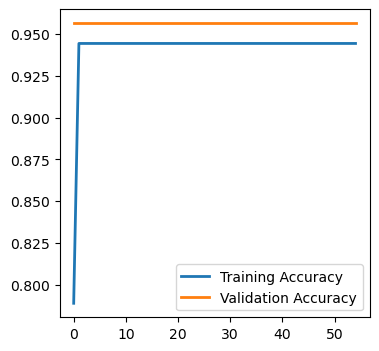

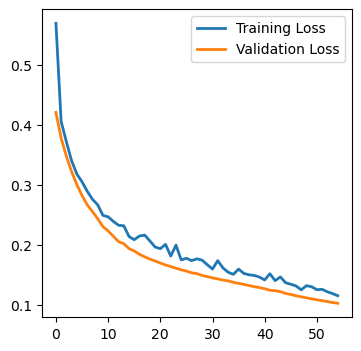

In [112]:
# get the number of epochs
# need to check why 
x = np.arange(max_iters)
plt.rcParams["figure.figsize"] = (4, 4)
plt.plot(x, train_acc_list, linewidth = 2, label = "Training Accuracy")
plt.plot(x, valid_acc_list, linewidth = 2, label = "Validation Accuracy")
plt.legend()
plt.show()

plt.plot(x, train_loss_list, linewidth = 2, label = "Training Loss")
plt.plot(x, valid_loss_list, linewidth = 2, label = "Validation Loss")
plt.legend()
plt.show()

In [113]:
import cv2
import numpy as np
# traditional Machine learnign modle 
# function to gather features using the Scale in-variant Feature Transform 
def extract_sift_features(images):
    sift = cv2.SIFT_create()
    all_descriptors = []
    img_descriptors = []    
    # compute the descriptors for image using the SIFT 
    for img in images:
        if img.dtype != np.uint8:
            img = (img * 255).astype(np.uint8)
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        # returns the key points, key descriptors 
        _, des = sift.detectAndCompute(img, None)
        if des is not None:
            all_descriptors.extend(des)
            img_descriptors.append(des)
        else:
            img_descriptors.append([])
    
    return img_descriptors, np.array(all_descriptors)

In [114]:
import sklearn
from sklearn.cluster import MiniBatchKMeans
# form feature vocabulary using Kmeans algorithm 
def build_vocab(descriptors, k=100):
    kmeans = MiniBatchKMeans(n_clusters=k, batch_size=k * 20, compute_labels=False, reassignment_ratio=10**-4, random_state=645)
    kmeans.fit(descriptors)
    return kmeans

In [63]:
# downgrading the numpy to avoid the sklearn KMeans is not working as I only get 'NoneType' object has no attribute 'split' on nonEmpty Array  
#!pip install numpy==1.26.2
#!pip install threadpoolctl==2.2.0
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable


In [143]:
# threadpool package in sklearn raises an issue 
# need to fix it 

Defaulting to user installation because normal site-packages is not writeable


In [115]:
# function to create histograms for image features 
def images_to_histograms(image_descriptors, kmeans_model):
    histograms = []
    for descriptors in image_descriptors:
        if len(descriptors) > 0:
            clusters = kmeans_model.predict(descriptors)
            hist, _ = np.histogram(clusters, bins=np.arange(kmeans_model.n_clusters + 1))
            histograms.append(hist)
        else:
            histograms.append(np.zeros((kmeans_model.n_clusters,)))
    return np.array(histograms)

In [116]:
# call the SIFT function 
# unit testing 
# Extract SIFT feature descriptors 
k = 10 
img_descriptors, all_descriptors = extract_sift_features(data['images'])
print (type ( img_descriptors))
print (len( all_descriptors))
#all_descriptors[0]
#todolist , debug the issue 
all_descriptors_f = list ( filter( lambda item: item is not None, all_descriptors) )
print (type (all_descriptors))
print (len( all_descriptors))
print (np.__version__)
# build the vocabularies for the feature descriptors of the image 
kmeans = build_vocab(all_descriptors_f[0:20], k)
#print (len( kmeans))
# Convert images to histogram representation
#histograms = images_to_histograms(img_descriptors, kmeans)
# numpy version 
#print (len( histograms))
# print (np.__version__) 1.26.2 

<class 'list'>
10674
<class 'numpy.ndarray'>
10674
1.26.2


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1902: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2048 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


In [130]:
# import the wrapper for svm and logistics regression 
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Extract SIFT feature descriptors 
img_descriptors, all_descriptors = extract_sift_features(data['images'])
# Create visual vocabulary
k = 100  # Number of visual words
kmeans = build_vocab(all_descriptors, k)
# Convert images to histogram representation
histograms = images_to_histograms(img_descriptors, kmeans)
# Split data
X_train, X_test, y_train, y_test = train_test_split(histograms, data['labels'], test_size=0.2, random_state=42)
# print the shape of all the train and test data 
print  ( 'the  shape of the   train and test data are  ' , X_train.shape, X_test.shape, y_train.shape, y_test.shape) 
# form the pipeline for standardize the data values , and call the Support vector classifiers 
svc_model = make_pipeline(StandardScaler(), SVC(kernel='linear'))
svc_model.fit(X_train, y_train)

# predic the model with test data 
y_pred = svc_model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.2f}")


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


the  shape of the   train and test data are   (180, 100) (46, 100) (180,) (46,)
Accuracy: 1.00


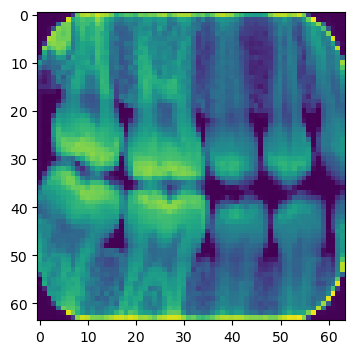

In [132]:
# unit testing 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
image_path = 'c:\\users\\19259\\project_data\\bytewings\\img2.jpeg' 
bitewing_img = mpimg.imread(image_path)
bitewing_img = cv2.resize(bitewing_img, (64, 64))
plt.imshow(bitewing_img)  
plt.show()


In [135]:
# unit testing 
# pass the bytwwing image and ensure whether the lable is identified as 2 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
sift = cv2.SIFT_create()
gray = cv2.cvtColor(bitewing_img,cv2.IMREAD_GRAYSCALE)
_, descriptors = sift.detectAndCompute(gray, None)
clusters = kmeans.predict(descriptors)
hist, _ = np.histogram(clusters, bins=np.arange(kmeans.n_clusters + 1))
hist = hist.reshape(1, -1)
predicted_class = svc_model.predict(hist)
print(predicted_class)

[2.]


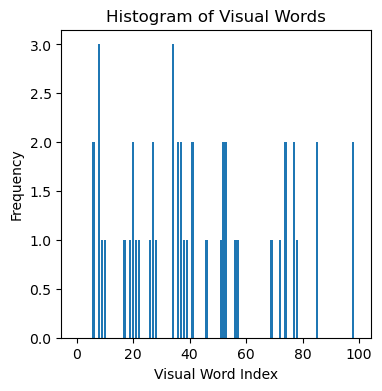

In [126]:
# pass the histograms daat prepared for the feature descriptors of the image and plt 
def visualize_histogram(histogram, k):
    plt.bar(range(k), histogram)
    plt.xlabel('Visual Word Index')
    plt.ylabel('Frequency')
    plt.title('Histogram of Visual Words')
    plt.show()

# unit testing     
visualize_histogram(histograms[0], k)


Accuracy: 1.00
[[22  0  0]
 [ 0  4  0]
 [ 0  0 20]]


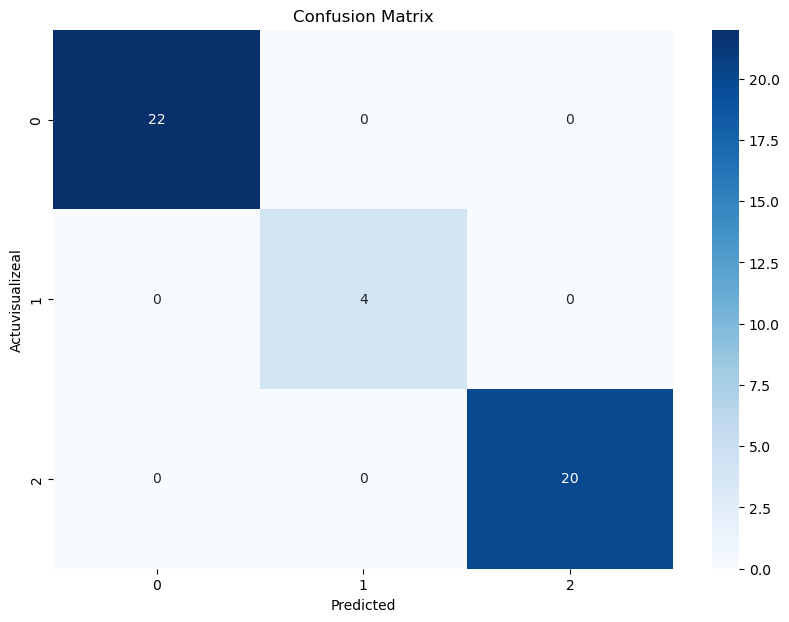

In [409]:
# option 2 
# call the  random foest classifier for the histogram 
# pass the feature vectors to the classical rndom 
from sklearn.ensemble import RandomForestClassifier
# split the data for train and test 
# fit the rfc for training data 
# form the pipeline for standardize the data values , and call the Support vector classifiers 
rfc_model = RandomForestClassifier()
rfc_model.fit(X_train, y_train)
# predic the model with test data 
pred_y = rfc_model.predict(X_test)
accuracy = np.mean(pred_y == y_test)
print(f"Accuracy: {accuracy:.2f}")
# Randomn forest classifier  Classification Report
# unit testing 
# pass the y_test (ground truth and y_pred values )
matrix = confusion_matrix(y_test, pred_y)
#report = visualize(y_test, pred_y)
print(matrix)
visualize(y_test, y_pred)


In [429]:
# try the logistics regression from skleran 
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
# instantiate LR type and intialize its parameters namely penelty, max_iter
LR_clf = LogisticRegression(fit_intercept=True,
                        multi_class='auto',
                        penalty='l2',  # L2 ridge regression 
                        #solver='saga', not required since the image dataset is very small 
                        max_iter=10000,
                        C=50) # regularization strength value 

In [424]:
# fit the model with the train data 
LR_clf.fit(X_train, y_train)
print ('list all the classifiers  '  , LR_clf.classes_ ) 
LR_clf.coef_.shape

list all the classifiers   [0. 1. 2.]


(3, 100)

<Axes: >

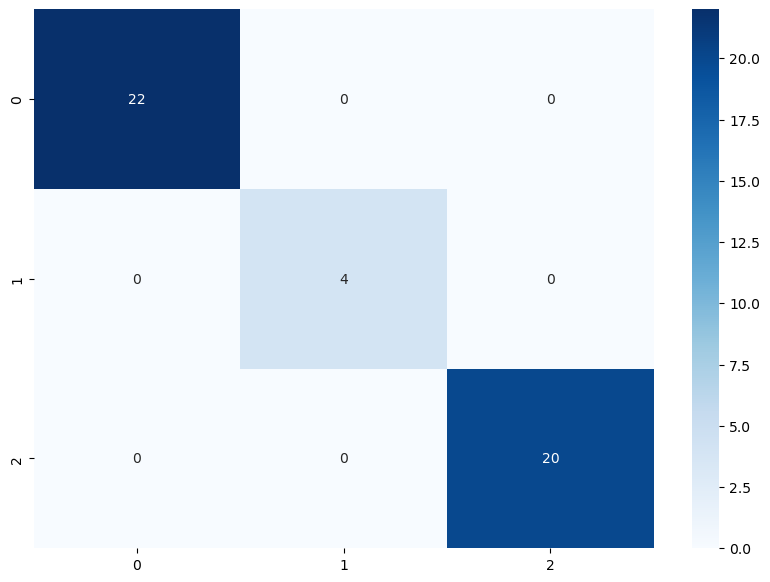

In [428]:
# predict the test data 
pred_y = LR_clf.predict(X_test)
confusion_matrix = metrics.confusion_matrix(y_true=y_test, 
                         y_pred = pred_y, 
                        labels = LR_clf.classes_)
#confusion_matrix
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')

In [420]:
# print the weights for all the classes 
LR_clf.coef_[0].round(2) # prints weights for 64*64 image for class 0
LR_clf.coef_[1].round(2) # prints weights for 64*64 image for class 0 >> 

array([-0.  ,  0.02, -0.08, -0.16, -0.09, -0.21, -0.01, -0.18, -0.26,
        0.4 ,  0.5 , -0.14, -0.25, -0.16, -0.25, -0.2 ,  0.04, -0.2 ,
        0.12, -0.19,  0.09,  0.1 , -0.07, -0.06, -0.06, -0.12, -0.23,
        0.3 , -0.55, -0.37, -0.13,  0.24, -0.1 , -0.14,  0.54,  0.04,
       -0.21, -0.43, -0.45,  0.05, -0.21, -0.4 , -0.22, -0.14, -0.15,
       -0.22, -0.35, -0.  , -0.2 , -0.21, -0.02, -0.03,  0.01, -0.33,
       -0.01, -0.06, -0.13,  0.09, -0.35,  0.32, -0.13,  0.4 , -0.15,
       -0.09, -0.06,  0.09, -0.28, -0.3 , -0.27,  0.29, -0.02, -0.23,
       -0.08, -0.14,  0.24,  0.36,  0.14, -0.06, -0.26,  0.02, -0.1 ,
       -0.06, -0.06,  0.01, -0.21, -0.16, -0.16,  0.01, -0.05,  0.06,
       -0.08, -0.28, -0.06,  0.55,  0.23,  0.05, -0.09,  0.1 , -0.12,
        0.  ])

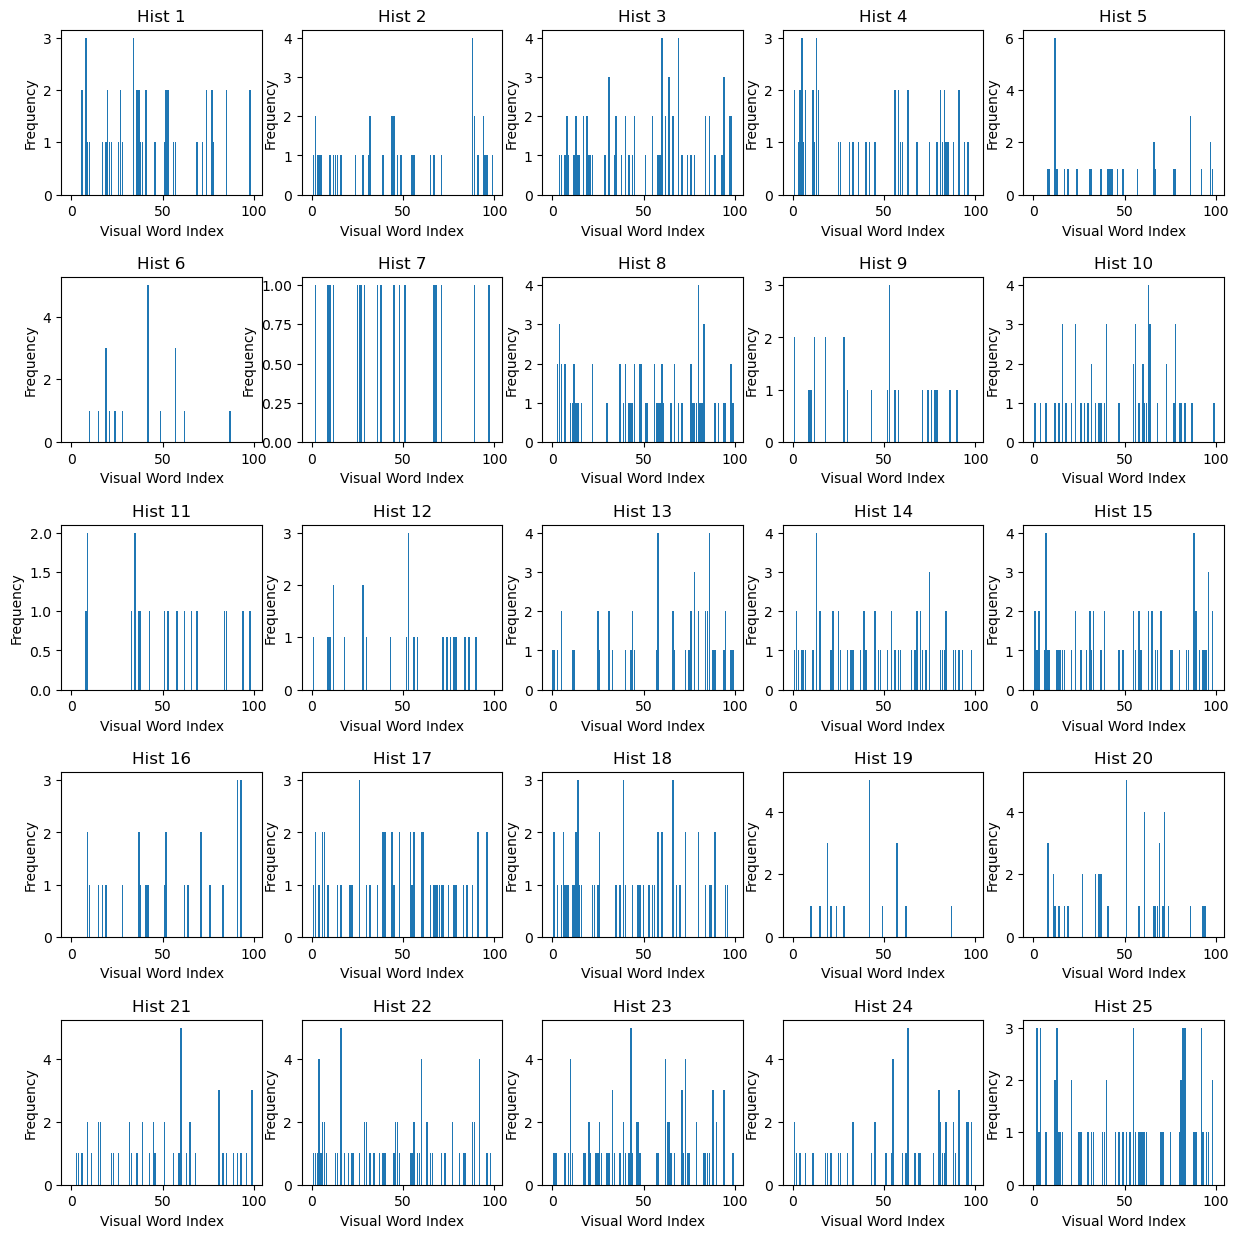

In [121]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have a list of histograms called "histograms"
# Each histogram should be a list or array of varying length

def visualize_histograms(histograms):
    num_histograms = len(histograms)
    num_rows = 5
    num_cols = 5
    num_plots = min(num_histograms, num_rows * num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 15))
    plt.subplots_adjust(hspace=.5)

    for i in range(num_plots):
        row = i // num_cols
        col = i % num_cols
        histogram = histograms[i]
        ax = axes[row, col]

        k = len(histogram)  # Get the length of the current histogram

        ax.bar(range(k), histogram)
        ax.set_xlabel('Visual Word Index')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Hist {i + 1}')

    # Remove empty subplots if necessary
    for i in range(num_plots, num_rows * num_cols):
        row = i // num_cols
        col = i % num_cols
        fig.delaxes(axes[row, col])

    plt.show()

# Example usage:
# Assuming histograms is a list of histograms with varying lengths
visualize_histograms(histograms)


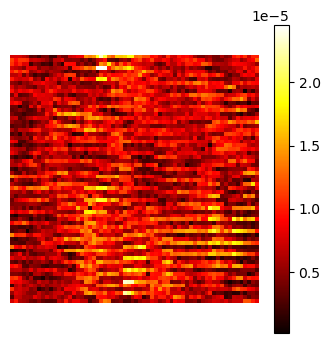

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Check if a GPU is available; otherwise, use CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Now, you can use the 'device' variable in your code
tensor = torch.randn(3, 3).to(device)  # Move a tensor to the specified device

# Ensure that your model is in evaluation mode
CNN_model.eval()

# Select a sample input from your data loader
for sample_input, _ in train_loader:
    sample_input = sample_input[0:1].to(device)  # take one image from the batch
    break

# Make sure the tensor requires gradient computation
sample_input.requires_grad = True

# Forward pass
output = CNN_model(sample_input)

# Get the index of the maximum value in the output (this will be our class label)
_, index = output.max(1)

# Zero out previous gradients
CNN_model.zero_grad()

# Backward pass
output[0, index].backward()

# Reshape the input and gradient to 3D
sample_input_3d = sample_input.view(3, 64, 64)
gradient_3d = sample_input.grad.view(3, 64, 64)

# Convert gradient to numpy
gradient_numpy = gradient_3d.cpu().detach().numpy()

# Compute heatmap
heatmap = np.linalg.norm(gradient_numpy, axis=0)

# Plot
plt.imshow(heatmap, cmap='hot')
plt.axis('off')
plt.colorbar()
plt.show()
